In [1]:
%matplotlib widget
import sphWarpCore_config as swc
from typing import Any
swc.configure(precision="float32", dim=Any) # precision: float16|half|float32|single|float64|double
# dim: int or "Any"
import warnings
from tqdm import TqdmExperimentalWarning
warnings.filterwarnings("ignore", category=TqdmExperimentalWarning)

import matplotlib.pyplot as plt
import os
import torch
os.environ['TORCH_CUDA_ARCH_LIST'] = f'{torch.cuda.get_device_properties(0).major}.{torch.cuda.get_device_properties(0).minor}'
import warp as wp; wp.init()

import torch
# from compressibleSPH.gencase import *
from compressibleSPH.sample import generateInitialVariables, SamplingScheme
from compressibleSPH.sampling import  sampleParticles
# from waves.util import plotState, plotInitialState
# from simulation import runSimulation
from compressibleSPH.utils import getCurrentTimestamp
from argparse import ArgumentParser
from compressibleSPH.casefile import argparse_defaults_from_casefile, load_casefile

# from compressibleSPH.systemv3 import WaveSystemStatev3
from compressibleSPH.sample import smoothState
# from compressibleSPH.systemv3 import WaveSystemv3, f_wave_equation
from integrators.integration import *
from compressibleSPH.utils import *
from sphWarpCore import *
# from compressibleSPH.systemv3 import WaveSystemStatev3

from sphWarpCore.radiusSearch.verlet import *
from sphWarpCore.radius import AdjacencyList
from sphWarpCore.operations import *
from sphWarpCore.enumTypes import *

from sphWarpCore import *
# from waves.sampling import sampleParticles
# from compressibleSPH.systemv3 import sampleInitialWaveState
# from compressibleSPH.systemv3 import computeDt
from compressibleSPH.sampling import finalizeWaveSystemSetup
from compressibleSPH.shape_generation import populateSourceObstacleGridsStructured

from compressibleSPH.config import SimulationConfig, CompressibleSPHConfig
from compressibleSPH.caseUtils.sod import *
from compressibleSPH.util import *
from compressibleSPH.schemes import *
from sphWarpCore.diffusion.viscosity import DiffusionParameters

from diffSPH.enums import ViscositySwitch, KernelType
from torch.profiler import profile, record_function, ProfilerActivity
from tqdm.autonotebook import tqdm

Warp 1.12.0 initialized:
   CUDA Toolkit 12.9, Driver 13.2
   Devices:
     "cpu"      : "x86_64"
     "cuda:0"   : "NVIDIA RTX PRO 500 Blackwell Generation Laptop GPU" (6 GiB, sm_120, mempool enabled)
   Kernel cache:
     /home/lu26029/.cache/warp/1.12.0


In [2]:

# from compressibleSPH.configurations.simulationConfig import SimulationConfig, buildConfig
# from compressibleSPH.schemeBuilder import buildScheme
# from compressibleSPH.caseUtils.sedov.initial import buildSedov
# goalRadius = 0.8

# gamma = 5/3
# rho0 = 1
# E0 = 1

# nx = 200
# # gamma = 5/3
# # leftState = sodInitialState(1, 1, 0)
# # rightState = sodInitialState(0.1795, 0.25, 0)
# samplingRatio = 1
# smoothIC = True
# timeLimit = 0.15

# L = 2
# dim = 2
# n_h = 4
# device = torch.device('cuda:0') if torch.cuda.is_available() else torch.device('cpu')
# dtype = torch.float32

# config = SimulationConfig(
#     domain = buildDomainDescription(L, dim, True, device, dtype),
#     dim = dim,
#     kernel = KernelFunctions.B7,
#     targetNeighbors = n_h_to_nH(n_h, dim),
#     supportMode = SupportScheme.Gather,
#     gradientMode = GradientScheme.Difference,
#     laplacianMode = LaplacianScheme.Brookshaw,
#     integrationScheme = IntegrationSchemeType.rungeKutta4,
#     samplingScheme = SamplingScheme.regular,
#     device = device,
#     dtype = dtype,
#     dt = 1e-3,
#     adaptiveDt = False,
#     cflFactor=0.3,
#     verletScale=1.0
# )



# SimulationSystem, SimulationState, SimulationConfig, fn = buildScheme('compSPH')

# compressibleSPHConfig = SimulationConfig(
#     gamma = gamma,
#     rho0 = rho0,
#     # diffusionParams = diffusionParams,
# )
# integrator = getIntegrator(config.integrationScheme)

# from compressibleSPH.enumTypes import ViscositySwitch
# compressibleSPHConfig.viscositySwitchParams.scheme = ViscositySwitch.CullenHopkins

In [141]:
nx = 200
gamma = 1.4
leftState = sodInitialState(1, 1, 0)
rightState = sodInitialState(0.1795, 0.25, 0)
samplingRatio = 1
smoothIC = True
timeLimit = 0.15

L = 10
dim = 2
n_h = 4
device = torch.device('cuda:0') if torch.cuda.is_available() else torch.device('cpu')
dtype = get_torch_precision()

config = SimulationConfig(
    domain = buildDomainDescription(L, dim, True, device, dtype),
    dim = dim,
    kernel = KernelFunctions.Wendland4,
    targetNeighbors = n_h_to_nH(n_h, dim),
    supportMode = SupportScheme.Gather,
    gradientMode = GradientScheme.Difference,
    laplacianMode = LaplacianScheme.Brookshaw,
    integrationScheme = IntegrationSchemeType.rungeKutta2,
    samplingScheme = SamplingScheme.regular,
    device = device,
    dtype = dtype,
    dt = 1e-3,
    adaptiveDt = False,
    cflFactor=0.3,
    # verletScale=1.0
)

# diffusionParams = DiffusionParameters()
# diffusionParams.c_s = 1
# diffusionParams.C_l = 1
# diffusionParams.C_q = 2
# diffusionParams.Cu_l = 1
# diffusionParams.Cu_q = 2
# diffusionParams.K = 1.0
# diffusionParams.thermalConductivity = 0.5
# diffusionParams.viscosityTerm = ViscosityTerms.Monaghan1992.value
# diffusionParams.thermalConducitiyTerm = ViscosityTerms.Price2012_98.value
# diffusionParams.scaleBeta = False
# diffusionParams.monaghanSwitch = True
# diffusionParams.correctXi = True


from compressibleSPH.configurations.simulationConfig import SimulationConfig, buildConfig
from compressibleSPH.schemeBuilder import buildScheme

SimulationSystem, SimulationState, SimulationConfig, fn = buildScheme('crkSPH')
rho0 = 1.0
compressibleSPHConfig = SimulationConfig(
    gamma = gamma,
    rho0 = rho0,
    # diffusionParams = diffusionParams,
)
integrator = getIntegrator(config.integrationScheme)

from compressibleSPH.enumTypes import ViscositySwitch
compressibleSPHConfig.viscositySwitchParams.scheme = ViscositySwitch.NoneSwitch

1 : r: 0.24963951110839844, n_hat: 3, shellAreaOptimized: 0.29296875, optimalArea: 0.29296875, ratio: 1.0
2 : r: 0.39183229207992554, n_hat: 4, shellAreaOptimized: 0.3906249701976776, optimalArea: 0.390625, ratio: 0.9999999403953552
3 : r: 0.5530583262443542, n_hat: 6, shellAreaOptimized: 0.5859375596046448, optimalArea: 0.5859375, ratio: 1.0000001192092896
4 : r: 0.712282657623291, n_hat: 8, shellAreaOptimized: 0.7812498807907104, optimalArea: 0.78125, ratio: 0.9999998211860657
5 : r: 0.8623548150062561, n_hat: 9, shellAreaOptimized: 0.8789061307907104, optimalArea: 0.87890625, ratio: 0.9999998807907104
6 : r: 1.0212082862854004, n_hat: 11, shellAreaOptimized: 1.074218511581421, optimalArea: 1.07421875, ratio: 0.9999997615814209
7 : r: 1.1732351779937744, n_hat: 12, shellAreaOptimized: 1.1718754768371582, optimalArea: 1.171875, ratio: 1.0000003576278687
8 : r: 1.3316981792449951, n_hat: 14, shellAreaOptimized: 1.3671875, optimalArea: 1.3671875, ratio: 1.0
9 : r: 1.484760046005249, n_h

Text(0.5, 1.0, 'Particle Positions')

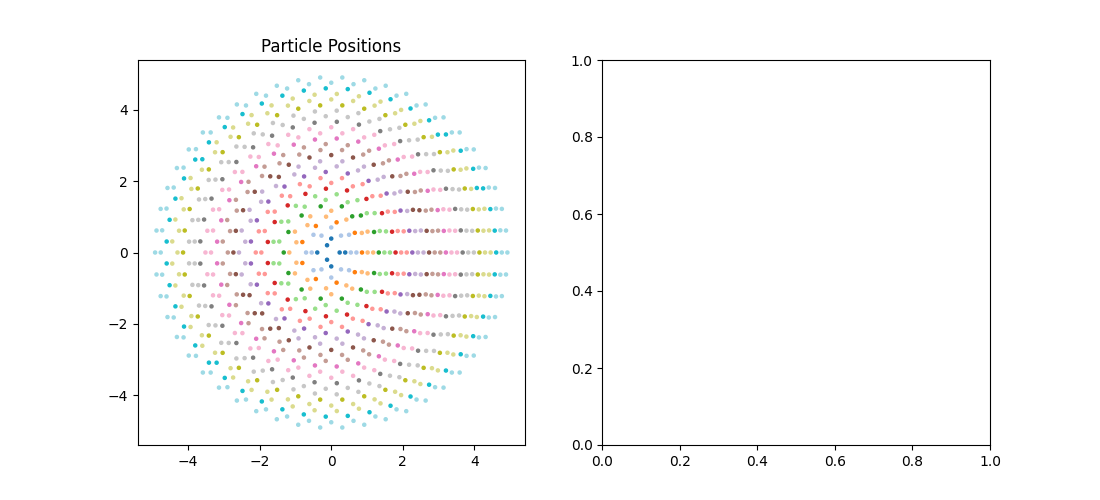

In [142]:
import random
from compressibleSPH.sampling import ParticleSet
from compressibleSPH.utils.support import volumeToSupportHelper

def sampleShell(nx, domain, targetNeighbors, circle = True, extraRings = 0):
    dx = (domain.max[0] - domain.min[0]) / nx
    # dx = dx.to(torch.float64)
    area = dx ** 2

    # print(area)
    # 
    # pi dr² = dx^2
    # dr = sqrt(dx^2/pi)
    dr_init = torch.sqrt(dx ** 2 / np.pi)
    dr_init = dx/2

    shells = []

    # shells.append((dr_init, torch.tensor([[0,0]], device = dx.device, dtype = dx.dtype), torch.tensor([dx**2], device = dx.device, dtype = dx.dtype)))

    # print(shells)
    remaining = extraRings
    for i in range(1, nx * 2):
        dr_hat = dr_init
        r_beg = torch.max(torch.hstack([s[1] for s in shells])) if len(shells) > 0 else dr_init
        r_end = r_beg + dr_hat

        shellArea = (np.pi * r_end ** 2 - np.pi * r_beg ** 2)
        # print(f'{i} : n_hat = {shellArea / area}')
        n_hat = torch.ceil(shellArea / area).to(torch.int32)

        optimalArea = n_hat * dx**2

        # pi (r_beg + dr)^2 - pi r_beg^2 = n_hat dx^2

        dr = torch.sqrt(r_beg**2 + n_hat * dx**2 / np.pi) - r_beg

        shellAreaOptimized = (np.pi * (r_beg + dr) ** 2 - np.pi * r_beg ** 2)
        # print(f'{i} : {shellAreaOptimized / optimalArea}, optimal Area: {optimalArea}, shell Area: {shellAreaOptimized}, {dr/ dr_hat}')

        dTheta = 2 * np.pi / n_hat
        theta = torch.linspace(0, 2 * np.pi, n_hat + 1, dtype = dx.dtype, device = dx.device)[:-1]

        theta += random.random() * dTheta*0

        x = (r_beg + dr_hat / 2) * torch.cos(theta)
        y = (r_beg + dr_hat / 2) * torch.sin(theta)
        pts = torch.stack([x,y], dim = 1)
        # print(pts.shape)
        areas = torch.ones(n_hat, device = dx.device, dtype = dx.dtype) * shellAreaOptimized / n_hat
        if circle:
            if r_beg + dr / 2> (domain.max[0] - domain.min[0]) / 2:
                remaining -= 1
                if (remaining < 0):
                    break
        else:
            insidePtcls = (pts[:, 0] > domain.min[0]) & (pts[:, 0] < domain.max[0]) & (pts[:, 1] > domain.min[1]) & (pts[:, 1] < domain.max[1])
            if not insidePtcls.any():
                remaining -= 1
                if (remaining < 0):
                    break
                # break
            pts = pts[insidePtcls]
            areas = areas[insidePtcls]

        shells.append((r_beg, r_end, dr, pts, areas))
        print(f'{i} : r: {r_beg + dr / 2}, n_hat: {n_hat}, shellAreaOptimized: {shellAreaOptimized}, optimalArea: {optimalArea}, ratio: {shellAreaOptimized / optimalArea}')


    positions = torch.vstack([s[3] for s in shells])
    areas = torch.hstack([s[4] for s in shells])

    # print(shellArea / optimalArea)

    
    supports = volumeToSupportHelper(areas, targetNeighbors, domain.dim)
    # supports = torch.ones_like(positions[:, 0]) * support

    return ParticleSet(
        positions = positions,
        supports = supports,
        masses = areas,
        densities = torch.ones_like(positions[:, 0])
    )


particles_ = sampleShell(32, config.domain, config.targetNeighbors, circle = True, extraRings=0)

fig, axis = plt.subplots(1, 2, figsize=(11,5), squeeze=False)

r = torch.norm(particles_.positions, dim=1)

axis[0,0].scatter(particles_.positions[:,0].cpu(), particles_.positions[:,1].cpu(), s=5, c=r.cpu(), cmap = 'tab20')
axis[0,0].set_title('Particle Positions')

In [143]:
3, 9, 16, 21

(3, 9, 16, 21)

dr: 0.15625, r_min: 0.078125, r_max: 4.921875
area: 0.02365708351135254
0 : r: 0.078125, n_hat: 3, shellArea: 0.07669904083013535, area: 0.02365708351135254, ratio: 1.0807057619094849
1 : r: 0.234375, n_hat: 9, shellArea: 0.23009712994098663, area: 0.02365708351135254, ratio: 1.0807057619094849
2 : r: 0.390625, n_hat: 16, shellArea: 0.3834952116012573, area: 0.02365708351135254, ratio: 1.0131616592407227
3 : r: 0.546875, n_hat: 22, shellArea: 0.5368933081626892, area: 0.02365708351135254, ratio: 1.0315828323364258
4 : r: 0.703125, n_hat: 29, shellArea: 0.6902913451194763, area: 0.02365708351135254, ratio: 1.0061743259429932
5 : r: 0.859375, n_hat: 35, shellArea: 0.8436894416809082, area: 0.02365708351135254, ratio: 1.018951177597046
6 : r: 1.015625, n_hat: 42, shellArea: 0.9970875382423401, area: 0.02365708351135254, ratio: 1.0035125017166138
7 : r: 1.171875, n_hat: 48, shellArea: 1.150485634803772, area: 0.02365708351135254, ratio: 1.0131616592407227
8 : r: 1.328125, n_hat: 55, shellA

Text(0.5, 1.0, 'Particle Positions')

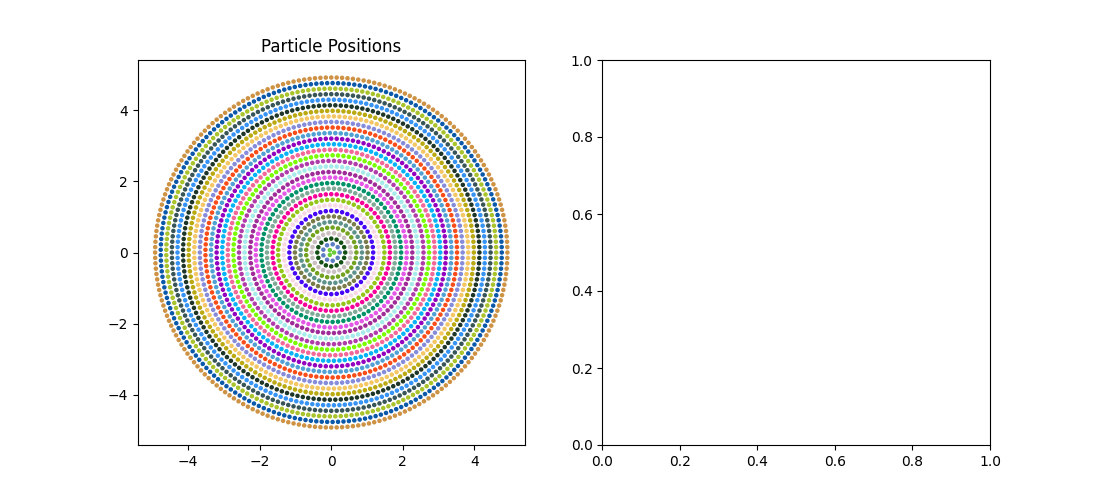

In [166]:
def sampleShellv2(nr, domain, targetNeighbors):
    L = domain.max[0] - domain.min[0]
    # For the shell sampling we first compute the dr, i.e., the thickness of each shell
    # We want to exclude the center point so we start sampling from dr/2 and then keep adding dr until we reach L/2 - dr/2
    # so we have
    # r_min = dr / 2
    # r_max = L / 2 - dr / 2
    # with nr = (r_max - r_min) / dr + 1
    # so 
    # nr = (L/2 - dr/2 - dr/2) / (dr + 1) = (L/2 - dr) / (dr + 1)
    dr = (L/2) / nr
    r_min = dr / 2
    r_max = L / 2 - dr / 2

    print(f'dr: {dr}, r_min: {r_min}, r_max: {r_max}')

    # for the particle area consider the total sampled domain from -r_max to r_max, which contains nr*2 particles.
    # so over 2 * r_max we have nr*2 particles, so the distance is 2 * r_max / (nr*2) = r_max / nr, so the area is (r_max / nr)^2
    area = (r_max / nr) ** 2

    print(f'area: {area}')

    shells = []
    for i in range(nr):
        r_begin = 0 + i * dr
        r_end = r_begin + dr
        shellArea = np.pi * (r_end ** 2 - r_begin ** 2)
        n_hat = torch.floor(shellArea / area).to(torch.int32)
        dTheta = 2 * np.pi / n_hat

        print(f'{i} : r: {r_begin + dr / 2}, n_hat: {n_hat}, shellArea: {shellArea}, area: {area}, ratio: {shellArea / (n_hat * area)}')

        theta = torch.linspace(0, 2 * np.pi, n_hat + 1, dtype = domain.min.dtype, device = domain.min.device)[:-1]
        x = (r_begin + dr / 2) * torch.cos(theta)
        y = (r_begin + dr / 2) * torch.sin(theta)
        pts = torch.stack([x,y], dim = 1)
        areas = torch.ones(n_hat, device = domain.min.device, dtype = domain.min.dtype) * shellArea / n_hat
        shells.append((i, r_begin, r_end, dr, pts, areas))

    positions = torch.vstack([s[4] for s in shells])
    areas = torch.hstack([s[5] for s in shells])
    supports = volumeToSupportHelper(areas, targetNeighbors, domain.dim)

    return ParticleSet(
        positions = positions,
        supports = supports,
        masses = areas,
        densities = torch.ones_like(positions[:, 0])
    ), shells

particles_, shells = sampleShellv2(32, config.domain, config.targetNeighbors)

fig, axis = plt.subplots(1, 2, figsize=(11,5), squeeze=False)

indices = torch.hstack([torch.ones(s[4].shape[0], device = particles_.positions.device, dtype = torch.int32) * s[0] for s in shells])
colors = torch.rand((len(shells), 3), device = particles_.positions.device)
sampledColors = colors[indices.long()]


r = torch.norm(particles_.positions, dim=1)

axis[0,0].scatter(particles_.positions[:,0].cpu(), particles_.positions[:,1].cpu(), s=5, c=sampledColors.cpu(), cmap = 'tab20')
axis[0,0].set_title('Particle Positions')

In [223]:
import math
xc = yc = 0
beta = 5
gamma = 1.4

r = torch.norm(particles_.positions, dim=1)

deltav_term = beta / (2 * math.pi) * torch.exp( ( 1 - r**2 ) / 2)
deltav_x = deltav_term * (- particles_.positions[:, 1] + yc)
deltav_y = deltav_term * (particles_.positions[:, 0] - xc)

deltaT = - ( ( gamma - 1) * beta**2 ) / ( 8 * gamma * math.pi**2 ) * torch.exp( 1 - r**2 )

P_infty = 1
rho_infty = 1
T_infty = P_infty / rho_infty

T = T_infty + deltaT
rhoInitial = T**(1 / (gamma - 1))
Pinitial = rhoInitial * T
uInitial = 1 / (gamma - 1) * (Pinitial / rhoInitial)

rho0 = 1

actualMasses = rhoInitial / rho0 * particles_.masses

v_initial = torch.stack([deltav_x, deltav_y], dim = 1)

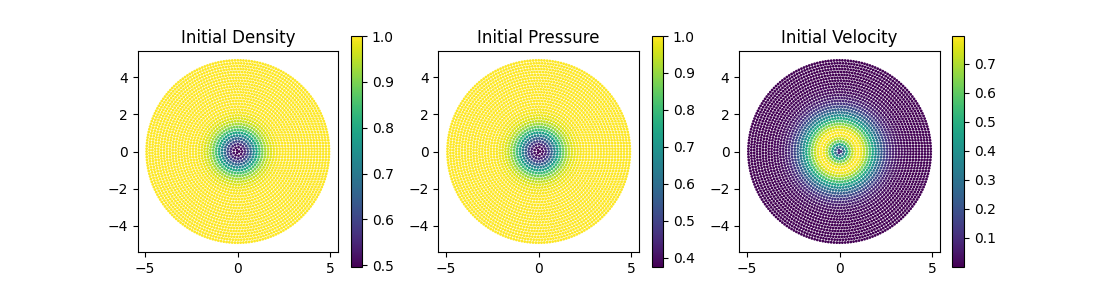

In [264]:
fig, axis = plt.subplots(1, 3, figsize=(11,3), squeeze=False)
s = 1

sc = axis[0,0].scatter(particles_.positions[:,0].cpu(), particles_.positions[:,1].cpu(), s=s, c=rhoInitial.cpu(), cmap = 'viridis')
fig.colorbar(sc, ax=axis[0,0])
axis[0,0].set_title('Initial Density')

sc = axis[0,1].scatter(particles_.positions[:,0].cpu(), particles_.positions[:,1].cpu(), s=s, c=Pinitial.cpu(), cmap = 'viridis')
fig.colorbar(sc, ax=axis[0,1])
axis[0,1].set_title('Initial Pressure')

sc = axis[0,2].scatter(particles_.positions[:,0].cpu(), particles_.positions[:,1].cpu(), s=s, c=torch.linalg.norm(v_initial,dim=1).cpu(), cmap = 'viridis')
fig.colorbar(sc, ax=axis[0,2])
axis[0,2].set_title('Initial Velocity')

for ax in axis.flatten():
    ax.set_aspect('equal')

In [225]:
def YeeVelocity(t_, x):
    return v_initial
def YeeDensity(t_, x):
    return rhoInitial
def YeeInternalEnergy(t_, x):
    return uInitial    
def YeeAcceleration(t_, x):
    return torch.zeros_like(x)

In [268]:
buffer_rings = 10
mask = indices >= (len(shells) - buffer_rings)
print(f'Buffer Particles: {mask.sum()} out of {len(particles_.positions)} [ {mask.sum() / len(particles_.positions) * 100:.2f}% ]')

def buffer_sdf(position):
    dist = torch.ones_like(position[:,0])
    dist[mask] = -1
    # dist[:] = -1
    return dist
def buffer_sdf_gradient(position):
    # for the gradient we set the non buffer particles to point outwards, and the buffer particles to point inwards
    dist = position.clone()
    dist[mask] = -dist[mask]
    return torch.nn.functional.normalize(dist, dim=1)

sdf = buffer_sdf(particles_.positions)
sdf_gradient = buffer_sdf_gradient(particles_.positions)

Buffer Particles: 1745 out of 3304 [ 52.81% ]


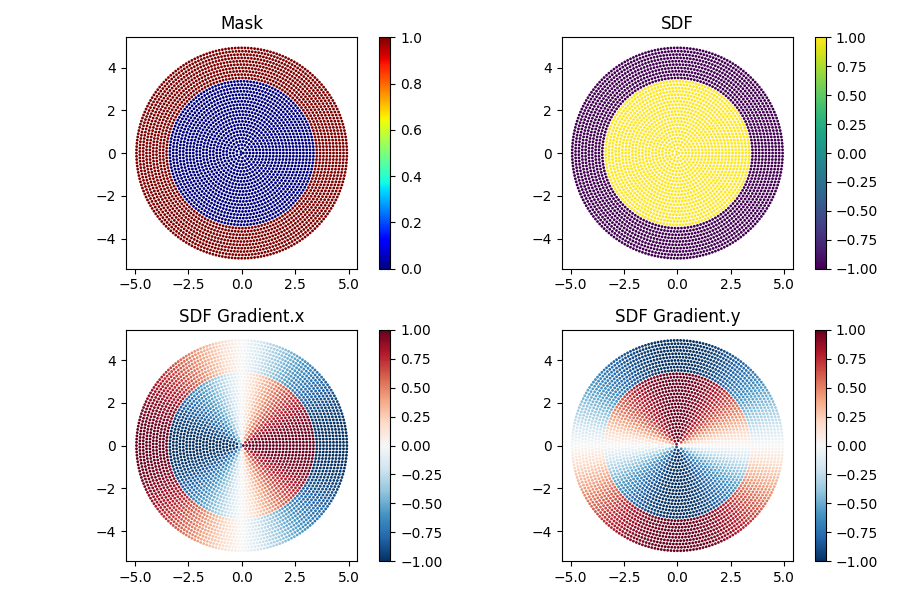

In [273]:
fig, axis = plt.subplots(2, 2, figsize=(9,6), squeeze=False)
s = 1

sc = axis[0,0].scatter(particles_.positions[:,0].cpu(), particles_.positions[:,1].cpu(), s=s, c=mask.cpu(), cmap = 'jet')
fig.colorbar(sc, ax=axis[0,0])
axis[0,0].set_title('Mask')

sc = axis[0,1].scatter(particles_.positions[:,0].cpu(), particles_.positions[:,1].cpu(), s=s, c=sdf.cpu(), cmap = 'viridis')
fig.colorbar(sc, ax=axis[0,1])
axis[0,1].set_title('SDF')

sc = axis[1,0].scatter(particles_.positions[:,0].cpu(), particles_.positions[:,1].cpu(), s=s, c=sdf_gradient[:,0].cpu(), cmap = 'RdBu_r')
fig.colorbar(sc, ax=axis[1,0])
axis[1,0].set_title('SDF Gradient.x')

sc = axis[1,1].scatter(particles_.positions[:,0].cpu(), particles_.positions[:,1].cpu(), s=s, c=sdf_gradient[:,1].cpu(), cmap = 'RdBu_r')
fig.colorbar(sc, ax=axis[1,1])
axis[1,1].set_title('SDF Gradient.y')

for ax in axis.flatten():
    ax.set_aspect('equal')

fig.tight_layout()

In [274]:
from compressibleSPH.boundaryConditions import *

yeeBC = BoundaryCondition(
    type = BoundaryConditionType.dynamic,
    sdf = lambda x: (buffer_sdf(x), buffer_sdf_gradient(x)),
    dirichletFunctions = {
        'velocities': lambda state, cfg, schemeCfg, positions, d, n, t, dt: YeeVelocity(t, positions),
        'densities': lambda state, cfg, schemeCfg, positions, d, n, t, dt: YeeDensity(t, positions),
        'internalEnergies': lambda state, cfg, schemeCfg, positions, d, n, t, dt: YeeInternalEnergy(t, positions),
    },
    updateFunctions = {
        'dvdt': lambda state, cfg, schemeCfg, positions, d, n, t, dt: YeeAcceleration(t, positions),
        'dxdt': lambda state, cfg, schemeCfg, positions, d, n, t, dt: YeeVelocity(t, positions),
    }
)
compressibleSPHConfig.boundaryConditions.clear()
compressibleSPHConfig.boundaryConditions.append(yeeBC)

In [275]:

from warp import Kernel

from compressibleSPH.config import SimulationConfig
from compressibleSPH.utils import *
from sphWarpCore import *
import torch
from compressibleSPH.system import *
from compressibleSPH.modules import idealGasEOS, evaluateOptimalSupport
from compressibleSPH.enumTypes import *
# from optimalSupport import evaluateOptimalSupport

# dim = 2
# domain = buildDomainDescription(L, dim, periodic = periodicDomain, device = device, dtype = dtype)

# particles_ = sampleRegularParticles(nx, config.domain, config.targetNeighbors)

# particles_ = sampleShell(32, config.domain, config.targetNeighbors, circle = True, extraRings=0)
print(f'Number of particles: {particles_.positions.shape[0]}')

# domain = buildDomainDescription(domainExtent * 1.5, dim, periodic = periodicDomain, device = device, dtype = dtype)
particles_ = particles_._replace(masses = particles_.masses * compressibleSPHConfig.rho0)



particles = SimulationState(
    positions = particles_.positions,
    supports = particles_.supports,
    masses = actualMasses,
    densities = particles_.densities,
    velocities = v_initial,
    
    kinds = torch.zeros_like(particles_.positions[:,0], dtype = torch.int32),
    materials = torch.zeros_like(particles_.positions[:,0], dtype = torch.int32),
    UIDs = torch.arange(particles_.positions.shape[0], device = device, dtype = torch.int32),
    UIDcounter = particles_.positions.shape[0],
    
    internalEnergies = None,
    totalEnergies = None,
    entropies = None,
    pressures = None,
    soundspeeds = None,

    divergence=torch.zeros_like(particles_.densities),
    alpha0s= torch.ones_like(particles_.densities),
    alphas= torch.ones_like(particles_.densities),
)


densities = warpOperation(
    particles, 
    OperationProperties(
        kernel = config.kernel,
        operation = WarpOperation.Density,
        supportMode = SupportScheme.Gather,
        gradientMode = config.gradientMode,
        laplacianMode = config.laplacianMode,
    ),
    domain = config.domain,
)
particles.densities = densities

compressibleSPHConfigAdapt = CompressibleSPHConfig(
    adaptiveSupportIterations=16,
    adaptiveSupportThreshold=1e-3,
    adaptiveSupportScheme=AdaptiveSupportScheme.NoScheme,
)

# neighborhood, neighbors = evaluateNeighborhood(particles, domain, wrappedKernel, verletScale = 1.0, mode = SupportScheme.SuperSymmetric, priorNeighborhood=None)
# numNeighbors = coo_to_csr(filterNeighborhoodByKind(particles, neighbors.neighbors, which = 'noghost')).rowEntries
# config = {'targetNeighbors': targetNeighbors, 'domain': domain, 'support': {'iterations': 16, 'scheme': 'Monaghan'}, 'neighborhood': {'algorithm': 'compact'}}
# rho, h, rhos, hs, neighborhood = evaluateOptimalSupport(particles, wrappedKernel, neighborhood, SupportScheme.Gather, config)


rho_optimal, h_optimal, adjacency, rhos_iter, supports_iter = evaluateOptimalSupport(particles, config, supportScheme = SupportScheme.Gather, compParams = compressibleSPHConfigAdapt)


adjacency = buildVerletList(particles, domain = config.domain, verletScale = 1.0, supportMode = SupportScheme.SuperSymmetric, priorNeighborhood=None, verbose=False)

print(f'Optimal Support min: {h_optimal.min()}, max: {h_optimal.max()}, mean: {h_optimal.mean()}')
print(f'Number of neighbors min: {adjacency.numNeighbors.min()}, max: {adjacency.numNeighbors.max()}, mean: {adjacency.numNeighbors.float().mean()}')

Number of particles: 3304
Optimal Support min: 0.6153044104576111, max: 0.639579176902771, mean: 0.6167129278182983
Number of neighbors min: 27, max: 56, mean: 47.463077545166016


In [276]:

# compressibleSPHConfig = CompressibleSPHConfig(
#     adaptiveSupportIterations=16,
#     adaptiveSupportThreshold=1e-3,
#     adaptiveSupportScheme=AdaptiveSupportScheme.Owen,
# )

# neighborhood, neighbors = evaluateNeighborhood(particles, domain, wrappedKernel, verletScale = 1.0, mode = SupportScheme.SuperSymmetric, priorNeighborhood=None)
# numNeighbors = coo_to_csr(filterNeighborhoodByKind(particles, neighbors.neighbors, which = 'noghost')).rowEntries
# config = {'targetNeighbors': targetNeighbors, 'domain': domain, 'support': {'iterations': 16, 'scheme': 'Monaghan'}, 'neighborhood': {'algorithm': 'compact'}}
# rho, h, rhos, hs, neighborhood = evaluateOptimalSupport(particles, wrappedKernel, neighborhood, SupportScheme.Gather, config)

rho_optimal, h_optimal, adjacency, rhos_iter, supports_iter = evaluateOptimalSupport(particles, config, supportScheme = SupportScheme.Gather, compParams = compressibleSPHConfigAdapt)



adjacency = buildVerletList(particles, domain = config.domain, verletScale = 1.0, supportMode = SupportScheme.SuperSymmetric, priorNeighborhood=None, verbose=False)

print(f'Optimal Support min: {h_optimal.min()}, max: {h_optimal.max()}, mean: {h_optimal.mean()}')
print(f'Number of neighbors min: {adjacency.numNeighbors.min()}, max: {adjacency.numNeighbors.max()}, mean: {adjacency.numNeighbors.float().mean()}')

Optimal Support min: 0.6153044104576111, max: 0.639579176902771, mean: 0.6167129278182983
Number of neighbors min: 27, max: 56, mean: 47.463077545166016


In [277]:

# particleState.supports = h_optimal

particles.densities = rho_optimal
particles.supports = h_optimal

# P_initial = torch.ones_like(particles.densities)
u = 1 / (gamma - 1) * (Pinitial / rho_optimal)
# A_, u_, P_, c_s = idealGasEOS(A = None, u = None, P = P_initial, rho = rho_optimal, gamma = gamma)
A_, u_, P_, c_s = idealGasEOS(A = None, u = u, P = None, rho = rho_optimal, gamma = gamma)

internalEnergy = u_ 
kineticEnergy = torch.linalg.norm(torch.zeros_like(particles.positions), dim = -1) **2/ 2
totalEnergy = (internalEnergy + kineticEnergy) * particles.masses

simulationState_ = SimulationState(
    positions = particles.positions,
    supports = particles.supports,
    masses = particles.masses,
    densities = particles.densities,        
    velocities = v_initial,

    kinds = torch.zeros_like(particles_.positions[:,0], dtype = torch.int32),
    materials = torch.zeros_like(particles_.positions[:,0], dtype = torch.int32),
    UIDs = torch.arange(particles_.positions.shape[0], device = device, dtype = torch.int32),
    UIDcounter = particles.positions.shape[0],
    
    internalEnergies = u_,
    totalEnergies = totalEnergy,
    entropies = A_,
    pressures = P_,
    soundspeeds = c_s,

    alphas = torch.ones_like(particles.densities),
    alpha0s = torch.ones_like(particles.densities),
    divergence=torch.zeros_like(particles.densities),
)
    

In [278]:
area = L**dim / (nx**dim)
rho_low = 1
rho_high = 2

# mask = torch.logical_and(particles.positions[:,0].abs() < L/4, particles.positions[:,1].abs() < L/4)

# simulationState_.masses[mask] = area * rho_high
# simulationState_.densities[mask] = rho_high
# simulationState_.masses[~mask] = area * rho_low
# simulationState_.densities[~mask] = rho_low

rho_optimal, h_optimal, adjacency, rhos_iter, supports_iter = evaluateOptimalSupport(particles, config, supportScheme = SupportScheme.Gather, compParams = compressibleSPHConfig)
# simulationState_.densities = rho_optimal
adjacency = buildVerletList(
    simulationState_, 
    config.domain, verletScale = 1.4, supportMode = SupportScheme.SuperSymmetric,
    priorNeighborhood = None,
    verbose = False)

apparentVolume, simulationState_.densities, crkState = computeCRKFactors(simulationState_, config.domain, config.kernel, adjacency = adjacency)


# P_initial = torch.ones_like(particles.densities)
# u = 1 / (gamma - 1) * (P_initial / simulationState_.densities)
# A_, u_, P_, c_s = idealGasEOS(A = None, u = None, P = P_initial, rho = rho_optimal, gamma = gamma)
A_, u_, P_, c_s = idealGasEOS(A = None, u = None, P = Pinitial, rho = simulationState_.densities, gamma = gamma)
simulationState_.internalEnergies = u_
simulationState_.pressures = P_
simulationState_.soundspeeds = c_s


print(f"min density: {simulationState_.densities.min()}, max density: {simulationState_.densities.max()}")
print(f"min mass: {simulationState_.masses.min()}, max mass: {simulationState_.masses.max()}")
print(f"min support: {simulationState_.supports.min()}, max support: {simulationState_.supports.max()}")

min density: 0.5313026309013367, max density: 1.000448226928711
min mass: 0.012687571346759796, max mass: 0.023858949542045593
min support: 0.6153044104576111, max support: 0.639579176902771


In [279]:
from compressibleSPH.modules.timestep.compressible import computeTimestep

In [280]:
adjacency = buildVerletList(simulationState_, 
                            domain = config.domain,
                            verletScale = 2**(1/config.dim), supportMode = config.supportMode)

compressibleSystem = SimulationSystem(
    state=simulationState_, 
    adjacency = adjacency, 
    domain = config.domain)

# particleSystem = SimulationSystem(
#     systemState = simulationState_,
#     domain = domain,
#     neighborhoodInfo = neighborhood,
#     t = 0
# )
config.adaptiveDt = True
config.dx = L / nx
config.dt = computeTimestep(compressibleSystem, config, compressibleSPHConfig, dt = None)
print(f'Initial timestep: {config.dt}')

Initial timestep: 0.009999999776482582


In [281]:
from compressibleSPH.schemes.compSPH import compSPH_step

In [282]:
# runningState = compSPHSystem.initializeNewState()

# result = integrator.function(
#     state = runningState,
#     f = compSPH_step,
#     dt = config.dt,  
#     config = config,
#     compParams = compSPHConfig,
#     verbose = False,|
# )
compressibleSPHConfig.energyScheme = EnergyScheme.CRK
compressibleSPHConfig.adaptiveSupportScheme = AdaptiveSupportScheme.NoScheme

In [283]:
runningState = compressibleSystem.initializeNewState()

In [284]:
display(compressibleSPHConfig)

CRKSPHConfig(gamma=1.4, backgroundPressure=0.0, rho0=1.0, adaptiveSupportScheme=<AdaptiveSupportScheme.NoScheme: 0>, adaptiveSupportIterations=1, adaptiveSupportThreshold=0.001, adaptiveSupportCorrections=True, diffusionParams=DiffusionParameters(
	c_s=1,
	C_l=1,
	C_q=1,
	Cu_l=1,
	Cu_q=1,
	K=1.0,
	thermalConductivity=0.5,
	viscosityTerm=3,
	thermalConducitiyTerm=7,
	scaleBeta=False,
	monaghanSwitch=True,
	correctXi=True,
), viscositySwitchParams=ViscositySwitchConfig(scheme=<ViscositySwitch.NoneSwitch: 6>, limitXi=True, correctVelocityGradient=False, divergenceScheme='naive', alpha_min=0.02, alpha_max=2.0, beta_c=0.7, beta_d=0.05, beta_xi=2.0), schemeName='CRKSPH', boundaryConditions=[BoundaryCondition(type=<BoundaryConditionType.dynamic: 'dynamic'>, sdf=<function <lambda> at 0x78e228ec1ee0>, dirichletFunctions={'velocities': <function <lambda> at 0x78e228ec1c60>, 'densities': <function <lambda> at 0x78e228ec3f60>, 'internalEnergies': <function <lambda> at 0x78e228ec3ec0>}, updateFunct

In [286]:
from warpPlot import visualize, PlottingOptions, PlotScaling, GridVisualization, UniformColorMap, Mapping, DivergingColorMap
markerSize = 32
plotter = visualize(
    particleState = runningState.state,
    domain = config.domain,
    quantities = {
        "A": runningState.state.velocities,
        "B": runningState.state.densities,
    },
    plotOptions = {
        "A": PlottingOptions(
            colorMap = UniformColorMap.viridis,
            markerSize = markerSize,
            midPoint = 0.0,
            quantityScaling = PlotScaling.Linear,
            mapping = Mapping.L2Norm,
            plotTitle = "velocities",
            # gridVisualization = GridVisualization(
            #     resolution = 512,
            # ),
            # vMin=1e-10
        ),
        "B": PlottingOptions(
            colorMap = UniformColorMap.cividis,
            flipColorMap=True,
            markerSize = markerSize,
            midPoint = 0.0,
            quantityScaling = PlotScaling.Linear,
            plotTitle = "densities",
            # gridVisualization = GridVisualization(
            #     resolution = 512,
            # ),
        ),
    },
    figTitle = "Wave Equation Example",
    mosaic = 'AB',
    figsize= (11,5),
    backend='vispy',
    # backend='pyVista',
    # backendOptions = {
    #     # In notebooks, use trame for reliable live updates.
    #     'jupyter_backend': 'trame',
    # }
)

# if args.exportImages:
#     plotter.export(f'output/{folderName}/frame_00000.png', dpi = args.figureDpi)

RFBOutputContext()

In [287]:
runningState.state.densities

tensor([0.5313, 0.5313, 0.5313,  ..., 0.9149, 0.9521, 0.9765], device='cuda:0')

In [288]:
print(config.dt)

0.009999999776482582


In [290]:
# config.dt = 2.5e-3
t_limit = 8.0
nSteps = int(t_limit / config.dt)

print(f"Running with dt: {config.dt}, which gives nSteps: {nSteps}")
# nSteps = 256

runningState = compressibleSystem.initializeNewState()

trajectory = []

priorStep = None
for i in (tq := tqdm(range(nSteps), leave = True)):
    begin = torch.cuda.Event(enable_timing=True)
    end = torch.cuda.Event(enable_timing=True)
    begin.record()
    result = integrator.function(
        state = runningState,
        f = fn,
        dt = config.dt,  
        config = config,
        compParams = compressibleSPHConfig,
        verbose = False,
        # priorStep = priorStep
    )
    end.record()
    torch.cuda.synchronize()
    priorStep = result.stages[-1]
    timing = begin.elapsed_time(end)

    runningState = result.state
    kineticEnergy = 0.5 * (torch.linalg.norm(runningState.state.velocities, dim = -1) **2 * runningState.state.masses).sum()
    thermalEnergy = (runningState.state.internalEnergies * runningState.state.masses).sum()
    totalEnergy = kineticEnergy + thermalEnergy

    trajectory.append(
        (i, (i+1)*config.dt, totalEnergy.item(), kineticEnergy.item(), thermalEnergy.item(), timing)
,     )


    if i % 10 == 0 and i > 0:
        plotter.updateQuantities(
            {
                "A": runningState.state.velocities,
                "B": runningState.state.densities,
            },
            newParticleState = runningState.state,
        )
        # axis[0,0].clear()
        # axis[0,1].clear()
        # axis[1,0].clear()
        # axis[1,1].clear()
        # plotShock(fig, axis, runningState)
        # fig.canvas.draw()
        # fig.canvas.flush_events()
        # fig.savefig(f'output/sedov/frame_{i:05d}.png', dpi = 300)

    maxVel = torch.linalg.norm(runningState.state.velocities, dim = -1).max()
    tq.set_description(f"Step {i+1}/{nSteps}, time: {(i+1)*config.dt:8.4g}/{t_limit:8.4g}, TE: {totalEnergy:.3g}, KE: {kineticEnergy:.3g}, IE: {thermalEnergy:.3g} | max vel: {maxVel:.3g} | iter time: {timing:.3f} ms")
    # t = {runningState.t:2f}, dt = {config.dt:.3g}, ptcls = {len(runningState.state.positions)}\nTotal Energy: {totalEnergy:.3g}, Kinetic Energy: {kineticEnergy:.3g}, Thermal Energy: {thermalEnergy:.3g}'
    # break

Running with dt: 0.009999999776482582, which gives nSteps: 800


  0%|          | 0/800 [00:00<?, ?it/s]

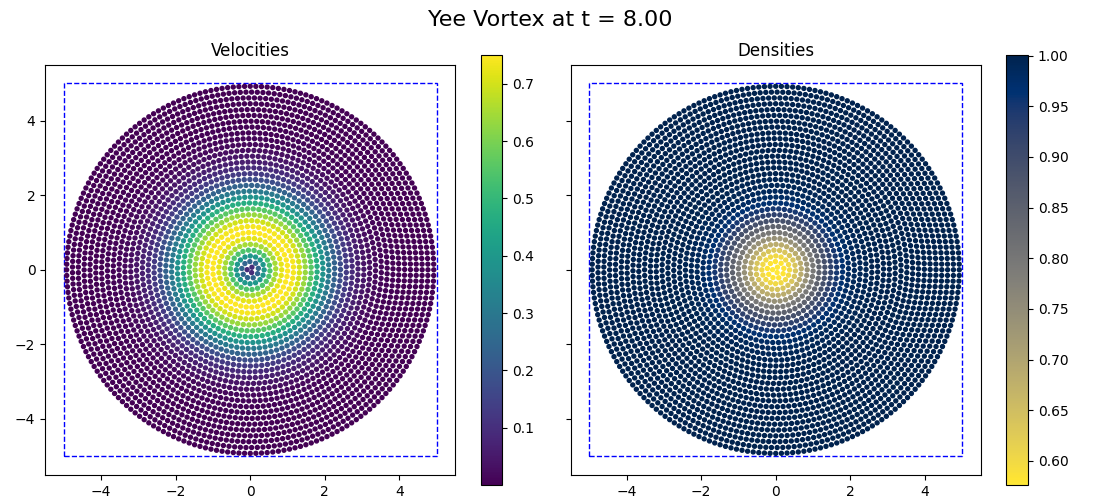

In [298]:
from warpPlot import visualize, PlottingOptions, PlotScaling, GridVisualization, UniformColorMap, Mapping, DivergingColorMap, MiscellaneousColorMap
markerSize = 8
plotter = visualize(
    particleState = runningState.state,
    domain = config.domain,
    quantities = {
        "A": runningState.state.velocities,
        "B": runningState.state.densities,
    },
    plotOptions = {
        "A": PlottingOptions(
            colorMap = UniformColorMap.viridis,
            markerSize = markerSize,
            midPoint = 0.0,
            quantityScaling = PlotScaling.Linear,
            mapping = Mapping.L2Norm,
            plotTitle = "Velocities",
            # gridVisualization = GridVisualization(
            #     resolution = 512,
            # ),
            # vMin=1e-10
        ),
        "B": PlottingOptions(
            colorMap = UniformColorMap.cividis,
            flipColorMap=True,
            markerSize = markerSize,
            midPoint = 0.0,
            quantityScaling = PlotScaling.Linear,
            plotTitle = "Densities",
            # gridVisualization = GridVisualization(
            #     resolution = 512,
            # ),
        ),
    },
    figTitle = f"Yee Vortex at t = {runningState.t:.2f}",
    mosaic = 'AB',
    figsize= (11,5),
    backend='matplotlib',
    # backend='pyVista',
    # backendOptions = {
    #     # In notebooks, use trame for reliable live updates.
    #     'jupyter_backend': 'trame',
    # }
)

# if args.exportImages:
#     plotter.export(f'output/{folderName}/frame_00000.png', dpi = args.figureDpi)